In [12]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)

In [13]:
(ds_train, ds_test), info = tfds.load(
    "cifar100",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

class_names = info.features['label'].names

In [14]:
IMG_SIZE = 96
BATCH_SIZE = 8

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Correct order
ds_train = ds_train.map(preprocess)
ds_train = ds_train.take(5000)     # reduce dataset
ds_train = ds_train.batch(BATCH_SIZE)

ds_test = ds_test.map(preprocess)
ds_test = ds_test.take(1000)
ds_test = ds_test.batch(BATCH_SIZE)

In [15]:
teacher = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(100)
])

teacher.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

teacher.fit(ds_train, epochs=1)

teacher.trainable = False

625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 152ms/step - accuracy: 0.0324 - loss: 4.4470


In [16]:
student = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(100)
])

In [17]:
temperature = 3
alpha = 0.3

ce_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
kl_loss = tf.keras.losses.KLDivergence()
optimizer = tf.keras.optimizers.Adam()

train_acc_list = []
train_loss_list = []

EPOCHS = 3

for epoch in range(EPOCHS):
    print("Epoch:", epoch+1)

    epoch_loss = 0
    correct = 0
    total = 0

    for images, labels in ds_train:
        with tf.GradientTape() as tape:

            teacher_preds = teacher(images, training=False)
            student_preds = student(images, training=True)

            soft_teacher = tf.nn.softmax(teacher_preds / temperature)
            soft_student = tf.nn.softmax(student_preds / temperature)

            loss_soft = kl_loss(soft_teacher, soft_student)
            loss_hard = ce_loss(labels, student_preds)

            loss = alpha * loss_soft + (1 - alpha) * loss_hard

        grads = tape.gradient(loss, student.trainable_variables)
        optimizer.apply_gradients(zip(grads, student.trainable_variables))

        epoch_loss += loss.numpy()

        preds = tf.argmax(student_preds, axis=1)
        correct += tf.reduce_sum(tf.cast(preds == labels, tf.int32)).numpy()
        total += labels.shape[0]

    epoch_acc = correct / total
    epoch_loss = epoch_loss / total

    train_acc_list.append(epoch_acc)
    train_loss_list.append(epoch_loss)

    print(f"Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

Epoch: 1
Loss: 0.4045, Accuracy: 0.0186
Epoch: 2
Loss: 0.3781, Accuracy: 0.0426
Epoch: 3
Loss: 0.3585, Accuracy: 0.0684


In [18]:
student.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

student.evaluate(ds_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.0670 - loss: 4.0890


[4.089012145996094, 0.06700000166893005]

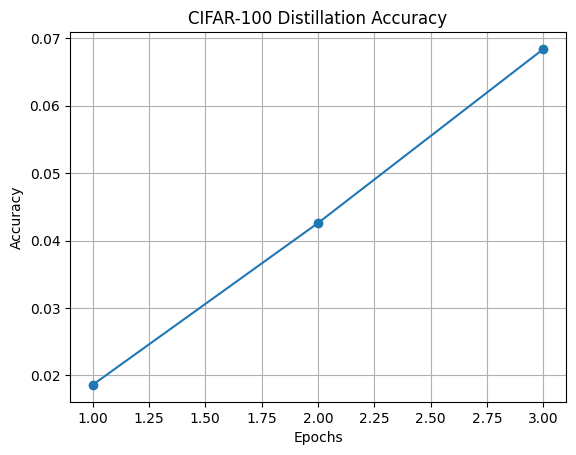

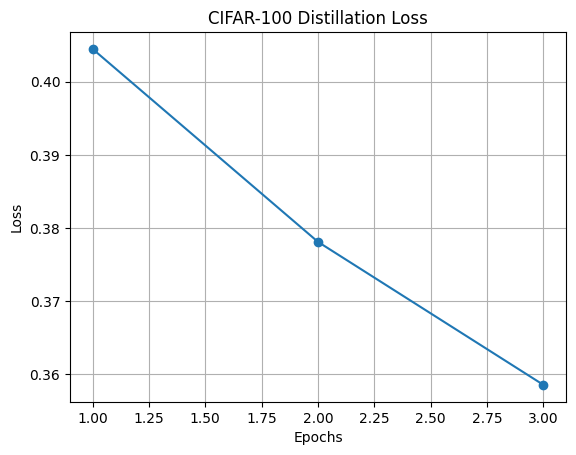

In [19]:
epochs_range = range(1, len(train_acc_list)+1)

# Accuracy
plt.figure()
plt.plot(epochs_range, train_acc_list, marker='o')
plt.title("CIFAR-100 Distillation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

# Loss
plt.figure()
plt.plot(epochs_range, train_loss_list, marker='o')
plt.title("CIFAR-100 Distillation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid()
plt.show()

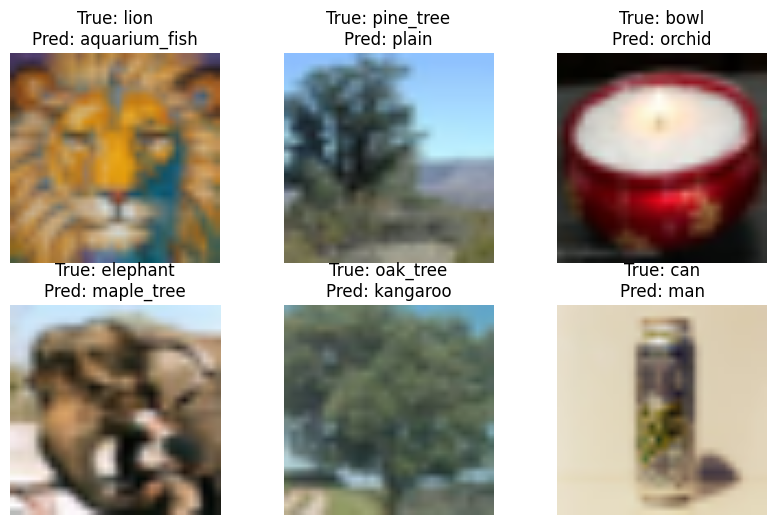

In [20]:
for images, labels in ds_test.take(1):

    preds = student(images, training=False)
    pred_labels = tf.argmax(preds, axis=1)

    plt.figure(figsize=(10,6))

    for i in range(min(6, len(images))):
        plt.subplot(2, 3, i+1)

        plt.imshow(images[i].numpy())
        plt.title(
            f"True: {class_names[labels[i]]}\n"
            f"Pred: {class_names[pred_labels[i]]}"
        )
        plt.axis("off")

    plt.show()